Descargando datos desde los servidores de VitalDB...


C:\Users\aparr\AppData\Local\Temp\ipykernel_11876\1654024743.py:8: DeprecationWarning: find_cases() relies on the per-track 'trks' index, which is deprecated and may be removed in a future release.
  caseids = vitaldb.find_cases(track_names)


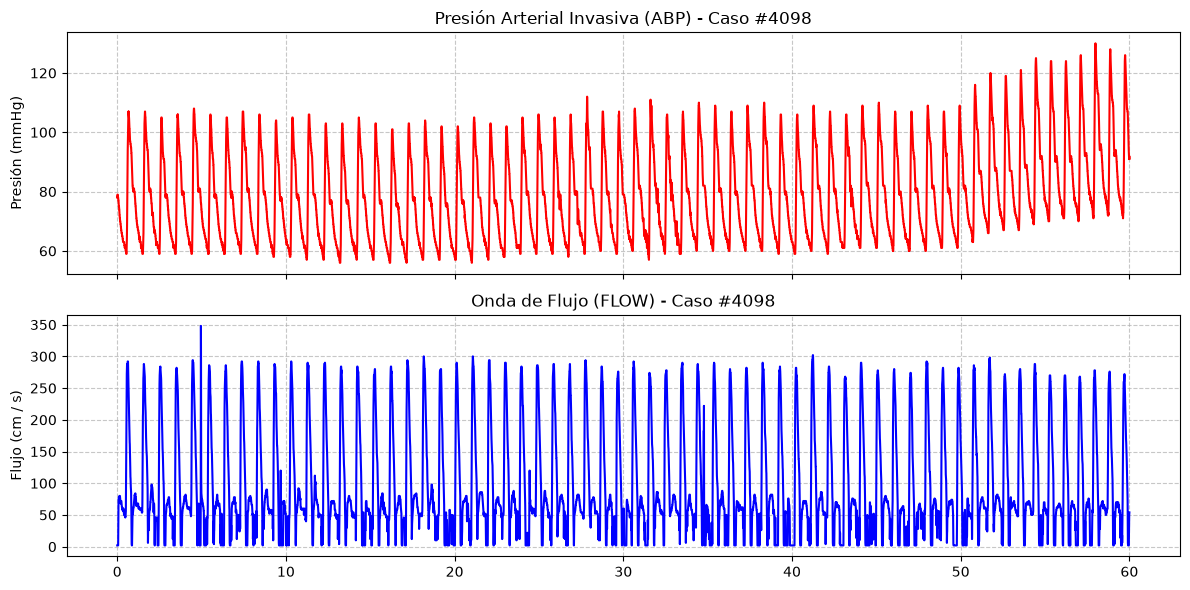

In [101]:
import numpy as np
import matplotlib.pyplot as plt
import vitaldb

track_names = ['CardioQ/ABP', 'CardioQ/FLOW']
print("Descargando datos desde los servidores de VitalDB...")
# Esto te da los caseid que tienen TODAS esas señales
caseids = vitaldb.find_cases(track_names)
FS = 180  # Hz
idx_chosen_patient = 1
CASE_ID = caseids[idx_chosen_patient]
vals = vitaldb.load_case(CASE_ID, track_names, 1 / FS)

art_signal = vals[:, 0]
ppg_signal = vals[:, 1]

valid_idx = ~np.isnan(art_signal) & ~np.isnan(ppg_signal)
art_signal = art_signal[valid_idx]
ppg_signal = ppg_signal[valid_idx]

WINDOW_SECONDS = 60
start_idx = 94000 + 90 * FS
end_idx = start_idx + WINDOW_SECONDS * FS

abp_window = art_signal[start_idx:end_idx]
qflow_window = ppg_signal[start_idx:end_idx]
time = np.linspace(0, WINDOW_SECONDS, len(abp_window))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

ax1.plot(time, abp_window, color='red', linewidth=1.5)
ax1.set_title(f'Presión Arterial Invasiva (ABP) - Caso #{CASE_ID}')
ax1.set_ylabel('Presión (mmHg)')
ax1.grid(True, linestyle='--', alpha=0.7)

ax2.plot(time, qflow_window, color='blue', linewidth=1.5)
ax2.set_title(f'Onda de Flujo (FLOW) - Caso #{CASE_ID}')
ax2.set_ylabel('Flujo (cm / s)')
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

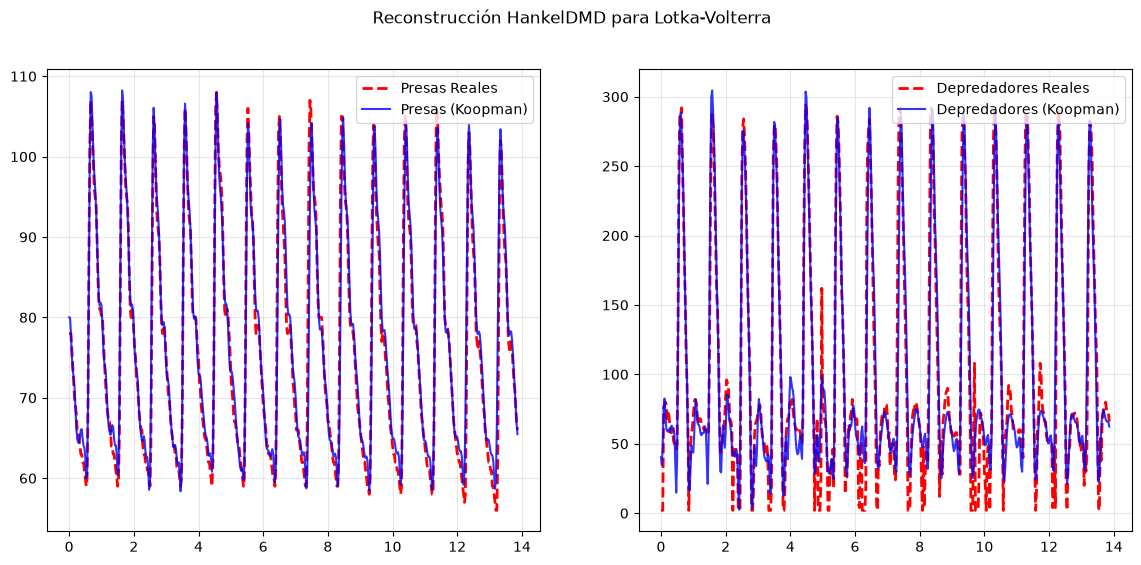

In [102]:
x1 = abp_window[:2500][::5]
x2 = qflow_window[:2500][::5]
t = time[:2500][::5]

x = np.stack([x1, x2])

from pydmd import HankelDMD

dmd = HankelDMD(svd_rank=24, d=200)
dmd.fit(x)

rec = dmd.reconstructed_data.real

# 5. Visualización
plt.figure(figsize=(14, 6))
plt.subplot(1,2,1)
plt.plot(t, x[0], 'r--', label='Presas Reales', linewidth=2)
plt.plot(t, rec[0], 'b-', label='Presas (Koopman)', alpha=0.8)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.subplot(1,2,2)
plt.plot(t, x[1], 'r--', label='Depredadores Reales', linewidth=2)
plt.plot(t, rec[1], 'b-', label='Depredadores (Koopman)', alpha=0.8)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.suptitle('Reconstrucción HankelDMD para Lotka-Volterra')
plt.show()

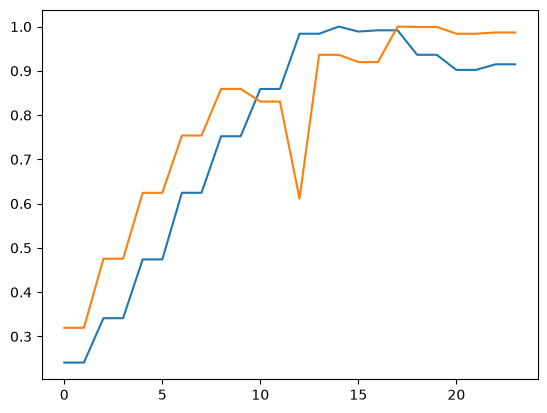

In [103]:
# 1. Tomar solo la señal de ABP (Presión Arterial)
x1_single = x1.reshape(1, -1)  # Dimensión: (1, 500)

# 2. Aplicar HankelDMD
dmd_single = HankelDMD(svd_rank=24, d=100)
dmd_single.fit(x1_single)

# 3. Reconstruir la señal
rec_single = dmd_single.reconstructed_data.real

# 4. Extraer los autovalores (frecuencias y amortiguamientos)
eigenvalues = dmd_single.eigs

plt.plot(dmd.eigs)
plt.plot(dmd_single.eigs)

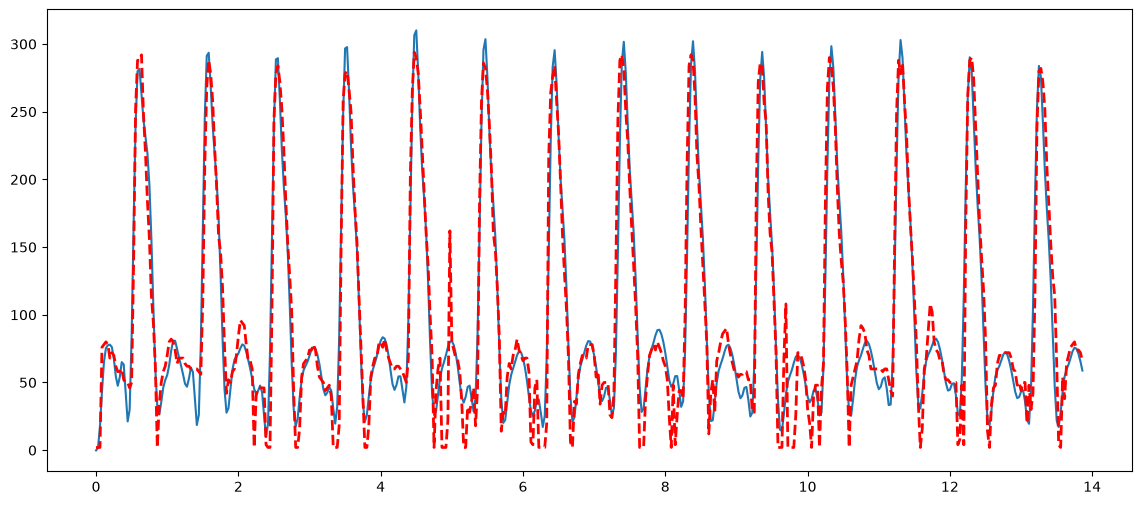

In [143]:
import numpy as np
from pydmd import HankelDMD

# 1. Entrenamos HankelDMD ÚNICAMENTE con la señal de Presión (x1)
x1_single = x1.reshape(1, -1)
dmd_x1 = HankelDMD(svd_rank=24, d=100)
dmd_x1.fit(x1_single)

# 2. Extraemos la matriz de dinámicas temporales exp(lambda * t) aprendidas de x1
# (Esta matriz contiene las frecuencias y amortiguamientos característicos)
time_dynamics = dmd_x1.dynamics  # Dimensión: (r, N)

# 3. Calculamos los pesos (modos) para x2 haciendo regresión mínimos cuadrados:
# x2 ~ phi_2 * time_dynamics
phi_2 = (x2 + 2.0 * np.random.normal(0,1,len(x2))) @ np.linalg.pinv(time_dynamics)

# 4. ¡Reconstruimos la señal de Flujo (x2) usando la dinámica aprendida de x1!
rec_x2_from_x1 = (phi_2 @ time_dynamics).real

plt.figure(figsize=(14, 6))
plt.plot(t, rec_x2_from_x1)
plt.plot(t, x[1], 'r--', label='Depredadores Reales', linewidth=2)

In [20]:
phi_2

array([ 0.56225745+2.69246976e-16j,  0.33710962+2.97088210e-02j,
        0.33710962-2.97088210e-02j, -0.54042338+5.40570408e-01j,
       -0.54042338-5.40570408e-01j, -0.24505596+5.32192627e-01j,
       -0.24505596-5.32192627e-01j, -0.02340255+9.78223077e-01j,
       -0.02340255-9.78223077e-01j, -0.82133137+3.07167705e-01j,
       -0.82133137-3.07167705e-01j,  0.0743129 -8.43538086e-01j,
        0.0743129 +8.43538086e-01j, -0.08003036+5.94741321e-01j,
       -0.08003036-5.94741321e-01j,  0.06019023+6.71033102e-01j,
        0.06019023-6.71033102e-01j, -0.87825122+4.62052832e-02j,
       -0.87825122-4.62052832e-02j, -0.52347078-4.06630682e-01j,
       -0.52347078+4.06630682e-01j,  0.0862224 -9.24761604e-18j,
        0.10784808+1.69163648e-01j,  0.10784808-1.69163648e-01j])

In [109]:
rmse_x1 = np.sqrt(np.mean((x[0] - rec[0])**2))
rmse_x2 = np.sqrt(np.mean((x[1] - rec_x2_from_x1)**2))
print(f"RMSE X1: {rmse_x1}")
print(f"RMSE X2: {rmse_x2}")
print()
print(f"RMSE RELATIVO X1: {100 * rmse_x1 / np.ptp(rec[0])} %")
print(f"RMSE RELATIVO X2: {100 * rmse_x2 / np.ptp(x[1])} %")
print()

Er_x1 = np.median(abs(x[0] - rec[0]) / np.ptp(rec[0]))
Er_x2 = np.median(abs(x[1] - rec_x2_from_x1) / np.ptp(x[1]))
print(f"ERROR MEDIANO RELATIVO X1: {100 * Er_x1} %")
print(f"ERROR MEDIANO RELATIVO X2: {100 * Er_x2} %")

RMSE X1: 2.9247116777884883
RMSE X2: 22.61380328161654

RMSE RELATIVO X1: 5.865284605367357 %
RMSE RELATIVO X2: 7.744453178635802 %

ERROR MEDIANO RELATIVO X1: 2.6575093382271717 %
ERROR MEDIANO RELATIVO X2: 3.8612514056949383 %
